In [1]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import roc_curve, roc_auc_score
from pathlib import Path
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import pickle
import os
oos_df_pred = pd.read_csv('~/Prepayment_Analysis_Data/prediction_df_oos.csv')
oos_df_true= pd.read_csv(os.path.expanduser('~/Prepayment_Analysis_Data/mort_for_testing.csv'))
path1 = os.path.expanduser('~/Prepayment_Analysis_Data/cloglog_model_results_slim.pkl')
path2 = os.path.expanduser('~/Prepayment_Analysis_Data/best_boost_model.pkl')
log_model = joblib.load(path1)
boost_model = joblib.load(path2)

In [2]:
oos_df_true[['refi_benefit_now', 'refi_benefit_past']].describe()

,refi_benefit_now,refi_benefit_past
count,4.646587e+06,4.646587e+06
mean,7.287075e+03,-7.583408e+03
std,2.602163e+04,2.515210e+04
min,-3.078144e+05,-3.462239e+05
25%,-6.332436e+03,-1.881697e+04
50%,4.647150e+03,-6.532111e+03
75%,1.818917e+04,3.874704e+03
max,6.212189e+05,5.061901e+05


In [ ]:
#Get oos predictions for logit model
X = oos_df_true[['LOAN_AGE', 'OLTV', 'CSCORE_MAX', 'coop_condo_dummy', 'refi_benefit_now', 'refi_benefit_past', 'hpi_growth', 'SATO']]
y = oos_df_true['PREPAY_FLAG']
X1 = sm.add_constant(X)
log_pred = log_model.predict(X1)

#Get oos predictions for the boost model
scaler_path = os.path.expanduser('~/Prepayment_Analysis_Data/scaler.pkl')
scaler = joblib.load(scaler_path)

X_train_scaled = scaler.transform(X)

# Convert to numpy if needed
X_train_scaled = X_train_scaled.astype('float32')
boost_pred = boost_model.predict(X_train_scaled)


In [4]:
log_pred.head()

0    0.006787
1    0.011127
2    0.011071
3    0.018238
4    0.016963
dtype: float64

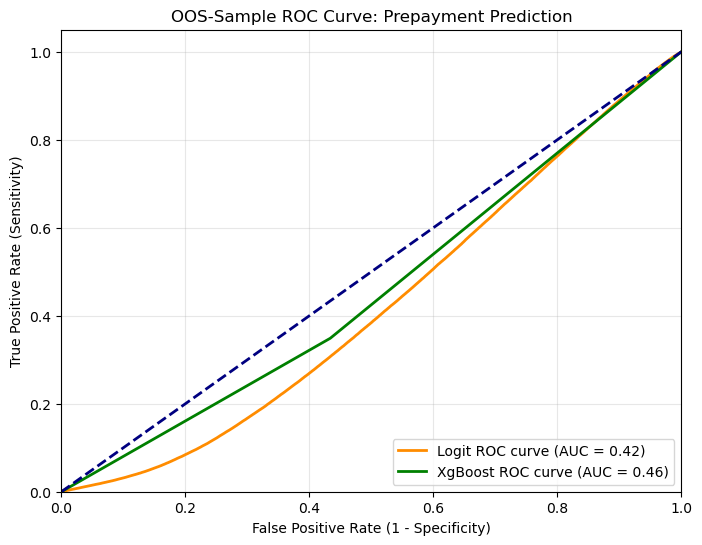

In [5]:
#Calculate the in-sample ROC values
fpr, tpr, thresholds = roc_curve(y, log_pred)
roc_auc = roc_auc_score(y, log_pred)

fpr_boost, tpr_boost, thresholds_boost = roc_curve(y, boost_pred)
roc_auc_boost = roc_auc_score(y, boost_pred)

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Logit ROC curve (AUC = {roc_auc:.2f})')
plt.plot(fpr_boost, tpr_boost, color='green', lw=2, label=f'XgBoost ROC curve (AUC = {roc_auc_boost:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Diagonal random line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('OOS-Sample ROC Curve: Prepayment Prediction')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [6]:
#Get actual cumulative prepayment rates by DATE_NOW
#Calculate original UPB
start_upb= oos_df_true[['LOAN_ID', 'ORIG_UPB']].drop_duplicates().set_index('LOAN_ID').sum().values[0]

oos_df_true['PREPAID_UPB'] = oos_df_true['PREPAY_FLAG'] * oos_df_true['ORIG_UPB']*oos_df_true['UPB_MULT']
cum_prepay = oos_df_true.groupby('DATE_NOW')['PREPAID_UPB'].sum().cumsum()/start_upb

In [ ]:
#get predicted cumulative prepayment rates by DATE_NOW for logit model
X_pred = oos_df_pred[['LOAN_AGE', 'OLTV', 'CSCORE_MAX', 'coop_condo_dummy', 'refi_benefit_now', 'refi_benefit_past', 'hpi_growth', 'SATO']]
X_pred1= sm.add_constant(X_pred)
oos_df_pred['PREDICTED_PREPAY_PROB'] = log_model.predict(X_pred1)
oos_df_pred['STAY_PROB'] = 1 - oos_df_pred['PREDICTED_PREPAY_PROB']

# 2. Ensure the data is ordered by loan and time
oos_df_pred = oos_df_pred.sort_values(['LOAN_ID', 'LOAN_AGE'])

# 3. Calculate the cumulative product (running product) per loan
# This gives: (1-P_0) * (1-P_1) * ... * (1-P_n)
oos_df_pred['CUM_STAY_PROB'] = oos_df_pred.groupby('LOAN_ID')['STAY_PROB'].cumprod()

# 4. Shift the results to get the product of PREVIOUS months only
oos_df_pred['LAG_PROD_SURVIVAL'] = (
    oos_df_pred.groupby('LOAN_ID')['CUM_STAY_PROB']
    .shift(1, fill_value=1.0)
)
oos_df_pred.drop(columns=['STAY_PROB', 'CUM_STAY_PROB'], inplace=True)
oos_df_pred['EXPECTED_PREPAID_UPB'] = oos_df_pred['ORIG_UPB'] * oos_df_pred['UPB_MULT']  * (oos_df_pred['LAG_PROD_SURVIVAL']) * oos_df_pred['PREDICTED_PREPAY_PROB']
agg_expected_prepay = oos_df_pred.groupby('DATE_NOW')['EXPECTED_PREPAID_UPB'].sum().cumsum()/start_upb


In [ ]:
#Repeat above cell for xgboost results
X_pred_scaled = scaler.transform(X_pred)
X_pred_scaled = X_pred_scaled.astype('float32')
y_prob_boost = boost_model.predict(X_pred_scaled)
# 1. Calculate the 'stay' probability for each specific month
oos_df_pred['PREDICTED_PREPAY_PROB_BOOST'] = y_prob_boost
oos_df_pred['STAY_PROB_BOOST'] = 1 - oos_df_pred['PREDICTED_PREPAY_PROB_BOOST']

# 2. Ensure the data is ordered by loan and time
oos_df_pred = oos_df_pred.sort_values(['LOAN_ID', 'LOAN_AGE'])

# 3. Calculate the cumulative product (running product) per loan
# This gives: (1-P_0) * (1-P_1) * ... * (1-P_n)
oos_df_pred['CUM_STAY_PROB_BOOST'] = oos_df_pred.groupby('LOAN_ID')['STAY_PROB_BOOST'].cumprod()

# 4. Shift the results to get the product of PREVIOUS months only
oos_df_pred['LAG_PROD_SURVIVAL_BOOST'] = (
    oos_df_pred.groupby('LOAN_ID')['CUM_STAY_PROB_BOOST']
    .shift(1, fill_value=1.0)
)
oos_df_pred.drop(columns=['STAY_PROB_BOOST', 'CUM_STAY_PROB_BOOST'], inplace=True)
oos_df_pred['EXPECTED_PREPAID_UPB_BOOST'] = oos_df_pred['ORIG_UPB'] * oos_df_pred['UPB_MULT']  * (oos_df_pred['LAG_PROD_SURVIVAL_BOOST']) * oos_df_pred['PREDICTED_PREPAY_PROB_BOOST']
agg_expected_prepay_boost = oos_df_pred.groupby('DATE_NOW')['EXPECTED_PREPAID_UPB_BOOST'].sum().cumsum()/start_upb



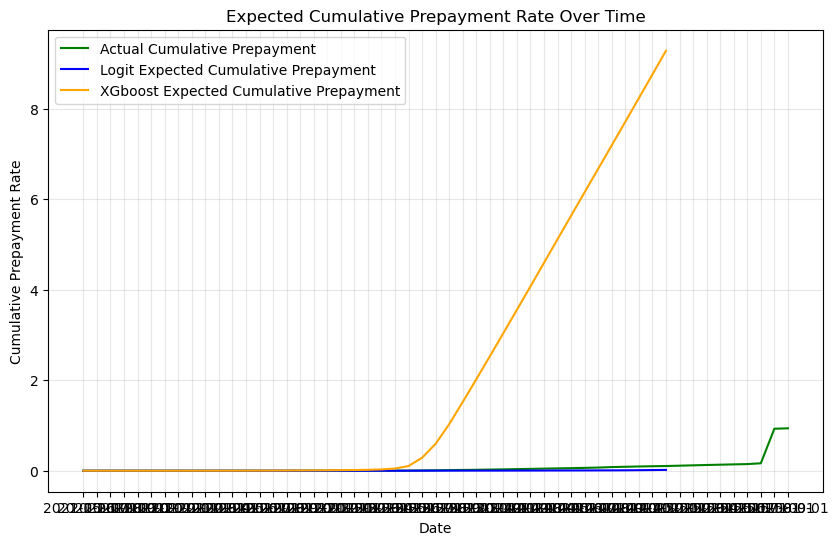

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(cum_prepay.index, cum_prepay.values, label='Actual Cumulative Prepayment', color='Green')
plt.plot(agg_expected_prepay.index, agg_expected_prepay.values, label='Logit Expected Cumulative Prepayment', color='Blue')
plt.plot(agg_expected_prepay_boost.index, agg_expected_prepay_boost.values, label='XGboost Expected Cumulative Prepayment', color='Orange')
plt.xlabel('Date')
plt.ylabel('Cumulative Prepayment Rate')
plt.title('Expected Cumulative Prepayment Rate Over Time')
plt.legend()
plt.grid(alpha=0.3)
plt.show()